# Exploratory Data Analysis
## Microsoft Azure Predictive Maintenance Dataset

This notebook works through the five raw tables one by one before anything is merged or modelled.

Tables covered:
- `PdM_telemetry.csv` — hourly sensor readings (volt, rotate, pressure, vibration)
- `PdM_errors.csv` — timestamped error events per machine
- `PdM_failures.csv` — component failure events per machine
- `PdM_maint.csv` — maintenance events per machine
- `PdM_machines.csv` — static machine metadata (model, age)

**Goals:**
1. Understand the structure and quality of each table
2. Find missing values and outliers
3. Quantify the class imbalance
4. Check whether sensor readings actually shift before failures
5. Build up enough intuition to make sensible feature engineering decisions

## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR  = '../data/raw'
FIG_DIR   = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

SENSORS = ['volt', 'rotate', 'pressure', 'vibration']
PALETTE = sns.color_palette('muted', 6)

## 2. Load Data

In [2]:
telemetry   = pd.read_csv(f'{DATA_DIR}/PdM_telemetry.csv', parse_dates=['datetime'])
errors      = pd.read_csv(f'{DATA_DIR}/PdM_errors.csv',    parse_dates=['datetime'])
failures    = pd.read_csv(f'{DATA_DIR}/PdM_failures.csv',  parse_dates=['datetime'])
maintenance = pd.read_csv(f'{DATA_DIR}/PdM_maint.csv',     parse_dates=['datetime'])
machines    = pd.read_csv(f'{DATA_DIR}/PdM_machines.csv')

tables = {
    'telemetry':   telemetry,
    'errors':      errors,
    'failures':    failures,
    'maintenance': maintenance,
    'machines':    machines,
}

print('Table shapes:')
for name, df in tables.items():
    print(f'  {name:12s}: {df.shape}')

Table shapes:
  telemetry   : (876100, 6)
  errors      : (3919, 3)
  failures    : (761, 3)
  maintenance : (3286, 3)
  machines    : (100, 3)


## 3. Data Overview

### 3.1 Schema and null checks

In [3]:
sep = "=" * 50
for name, df in tables.items():
    print()
    print(sep)
    print("  " + name.upper())
    print(sep)
    print(df.dtypes.to_string())
    nulls = df.isnull().sum()
    null_dict = nulls[nulls > 0].to_dict()
    print("Null counts:", null_dict if null_dict else "none")



  TELEMETRY
datetime     datetime64[ns]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
Null counts: none

  ERRORS
datetime     datetime64[ns]
machineID             int64
errorID              object
Null counts: none

  FAILURES
datetime     datetime64[ns]
machineID             int64
failure              object
Null counts: none

  MAINTENANCE
datetime     datetime64[ns]
machineID             int64
comp                 object
Null counts: none

  MACHINES
machineID     int64
model        object
age           int64
Null counts: none


### 3.2 Sample rows from each table

In [4]:
for name, df in tables.items():
    print(f'\n--- {name} ---')
    display(df.head(3))


--- telemetry ---


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847



--- errors ---


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5



--- failures ---


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2



--- maintenance ---


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3



--- machines ---


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8


## 4. Time Coverage

All five tables should span the same observation period. Verifying this is important before any time-based merging.

In [5]:
time_tables = {
    'telemetry':   telemetry,
    'errors':      errors,
    'failures':    failures,
    'maintenance': maintenance,
}

coverage = pd.DataFrame([
    {'table': name, 'start': df['datetime'].min(), 'end': df['datetime'].max(),
     'days': (df['datetime'].max() - df['datetime'].min()).days}
    for name, df in time_tables.items()
])
display(coverage)

,table,start,end,days
0,telemetry,2015-01-01 06:00:00,2016-01-01 06:00:00,365
1,errors,2015-01-01 06:00:00,2016-01-01 05:00:00,364
2,failures,2015-01-02 03:00:00,2015-12-31 06:00:00,363
3,maintenance,2014-06-01 06:00:00,2016-01-01 06:00:00,579


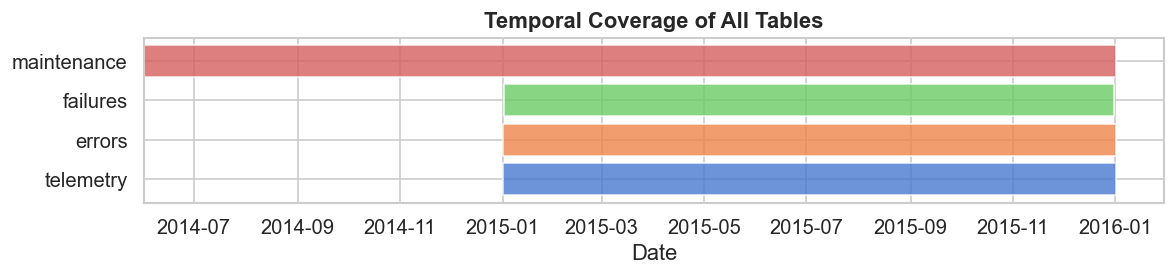

In [6]:
fig, ax = plt.subplots(figsize=(10, 2.5))
colors = sns.color_palette('muted', len(time_tables))

for i, (name, df) in enumerate(time_tables.items()):
    ax.barh(name, left=df['datetime'].min(), width=df['datetime'].max() - df['datetime'].min(),
            color=colors[i], alpha=0.8)

ax.set_xlabel('Date')
ax.set_title('Temporal Coverage of All Tables', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/temporal_coverage.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Telemetry Analysis

The telemetry table has 876,100 hourly readings across 100 machines for the whole of 2015.

### 5.1 Descriptive statistics

In [7]:
display(telemetry[SENSORS].describe().round(3))

,volt,rotate,pressure,vibration
count,876100.000,876100.000,876100.000,876100.000
mean,170.778,446.605,100.859,40.385
std,15.509,52.674,11.049,5.370
min,97.334,138.432,51.237,14.877
25%,160.305,412.306,93.498,36.777
50%,170.607,447.558,100.426,40.237
75%,181.004,482.177,107.555,43.785
max,255.125,695.021,185.952,76.791


### 5.2 Sensor distributions

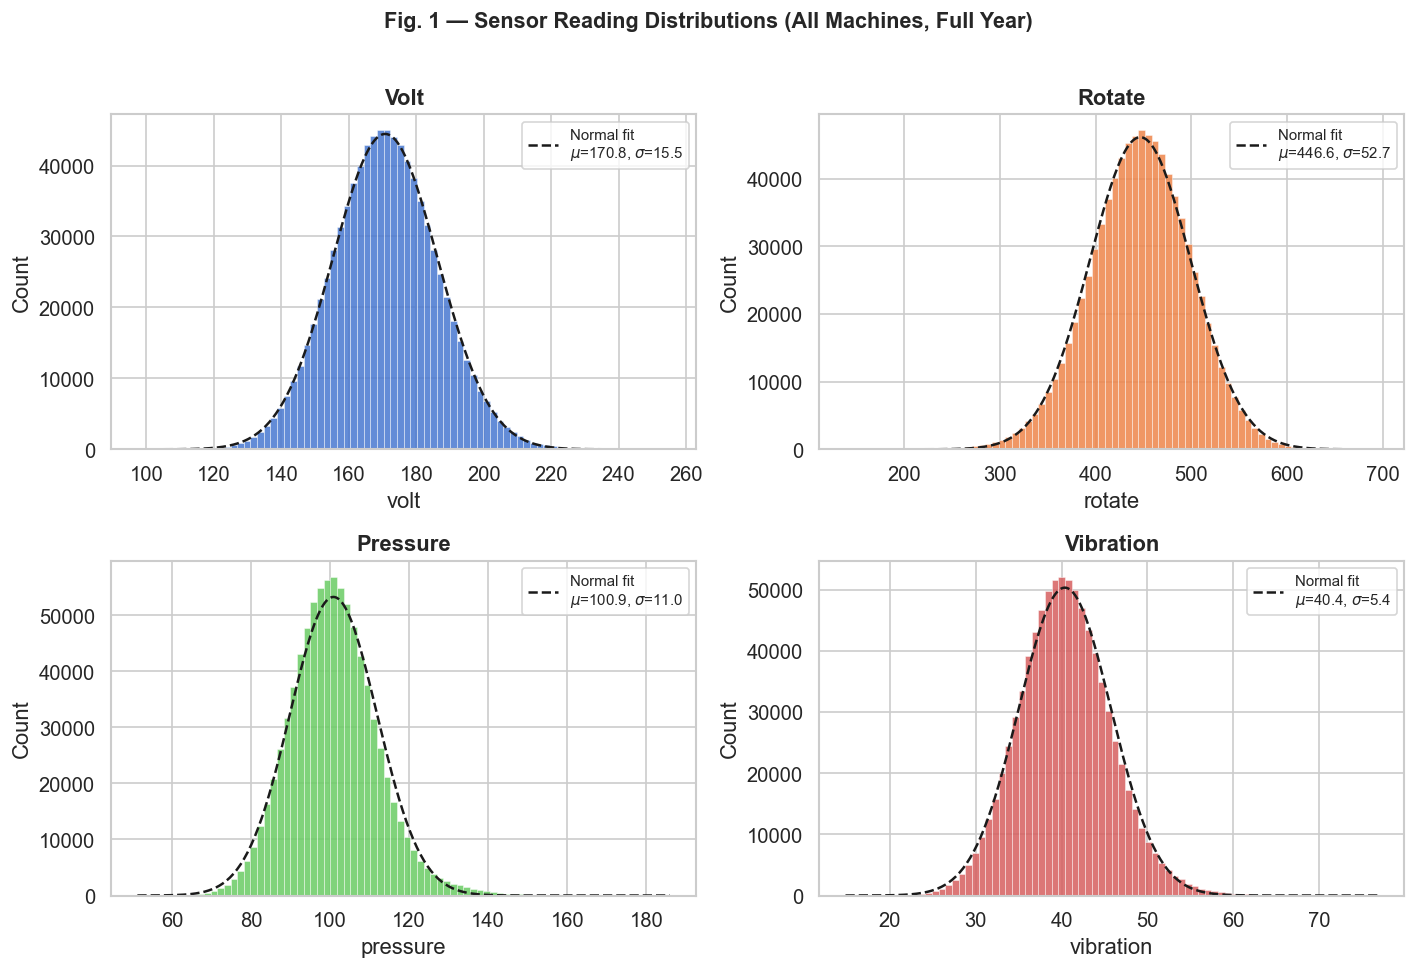

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, sensor in enumerate(SENSORS):
    data = telemetry[sensor]
    axes[i].hist(data, bins=80, color=PALETTE[i], edgecolor='white', linewidth=0.3, alpha=0.85)

    # Overlay normal distribution fit
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma) * len(data) * (data.max() - data.min()) / 80
    axes[i].plot(x, pdf, 'k--', linewidth=1.5, label=f'Normal fit\n$\mu$={mu:.1f}, $\sigma$={sigma:.1f}')

    axes[i].set_title(f'{sensor.capitalize()}', fontweight='bold')
    axes[i].set_xlabel(sensor)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Fig. 1 — Sensor Reading Distributions (All Machines, Full Year)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sensor_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.3 Boxplots

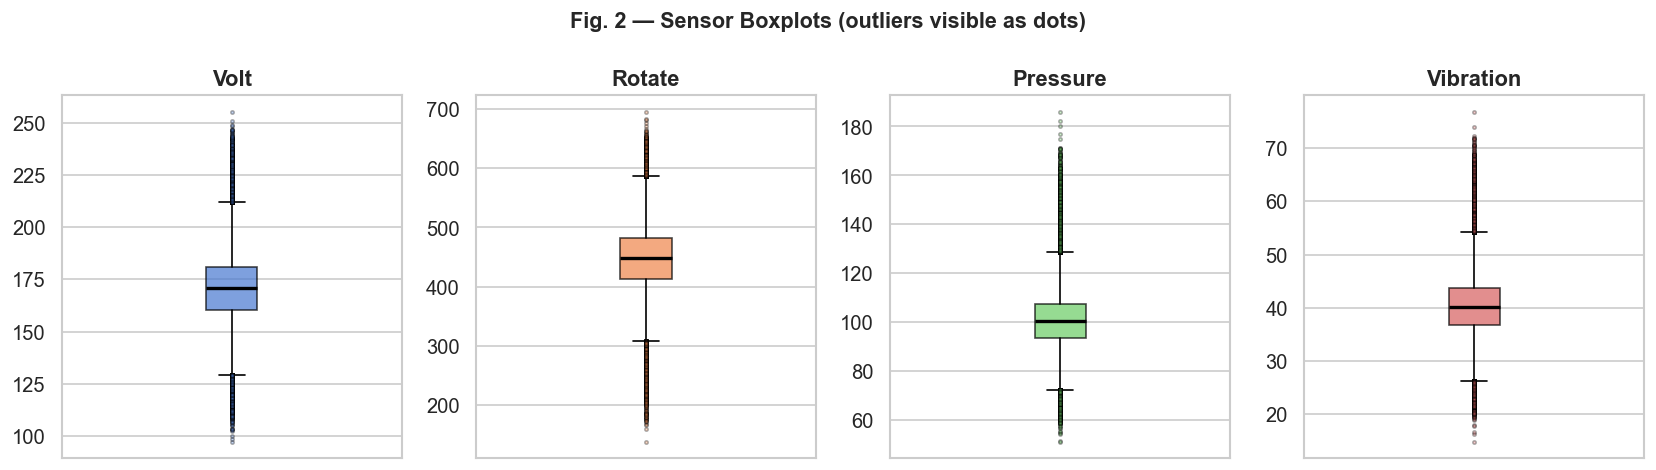

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, sensor in enumerate(SENSORS):
    axes[i].boxplot(telemetry[sensor].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=PALETTE[i],
                                   markersize=2, alpha=0.3))
    axes[i].set_title(sensor.capitalize(), fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('Fig. 2 — Sensor Boxplots (outliers visible as dots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sensor_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.4 Outlier analysis (IQR method)

Outliers are defined as values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.

In [10]:
outlier_summary = []
for sensor in SENSORS:
    q1, q3 = telemetry[sensor].quantile(0.25), telemetry[sensor].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((telemetry[sensor] < lower) | (telemetry[sensor] > upper)).sum()
    outlier_summary.append({
        'sensor': sensor,
        'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
        'lower_fence': round(lower, 2), 'upper_fence': round(upper, 2),
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(telemetry) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)
print('\nOutlier rates are all <2% — consistent with sensor noise, not systematic errors.')

,sensor,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,pct_outliers
0,volt,160.30,181.00,20.70,129.26,212.05,7466,0.85
1,rotate,412.31,482.18,69.87,307.50,586.98,8568,0.98
2,pressure,93.50,107.56,14.06,72.41,128.64,15587,1.78
3,vibration,36.78,43.78,7.01,26.27,54.30,11111,1.27



Outlier rates are all <2% — consistent with sensor noise, not systematic errors.


### 5.5 Sensor readings over time (one machine)

Plotting one machine's sensor readings for January 2015 gives intuition about the signal frequency and noise level.

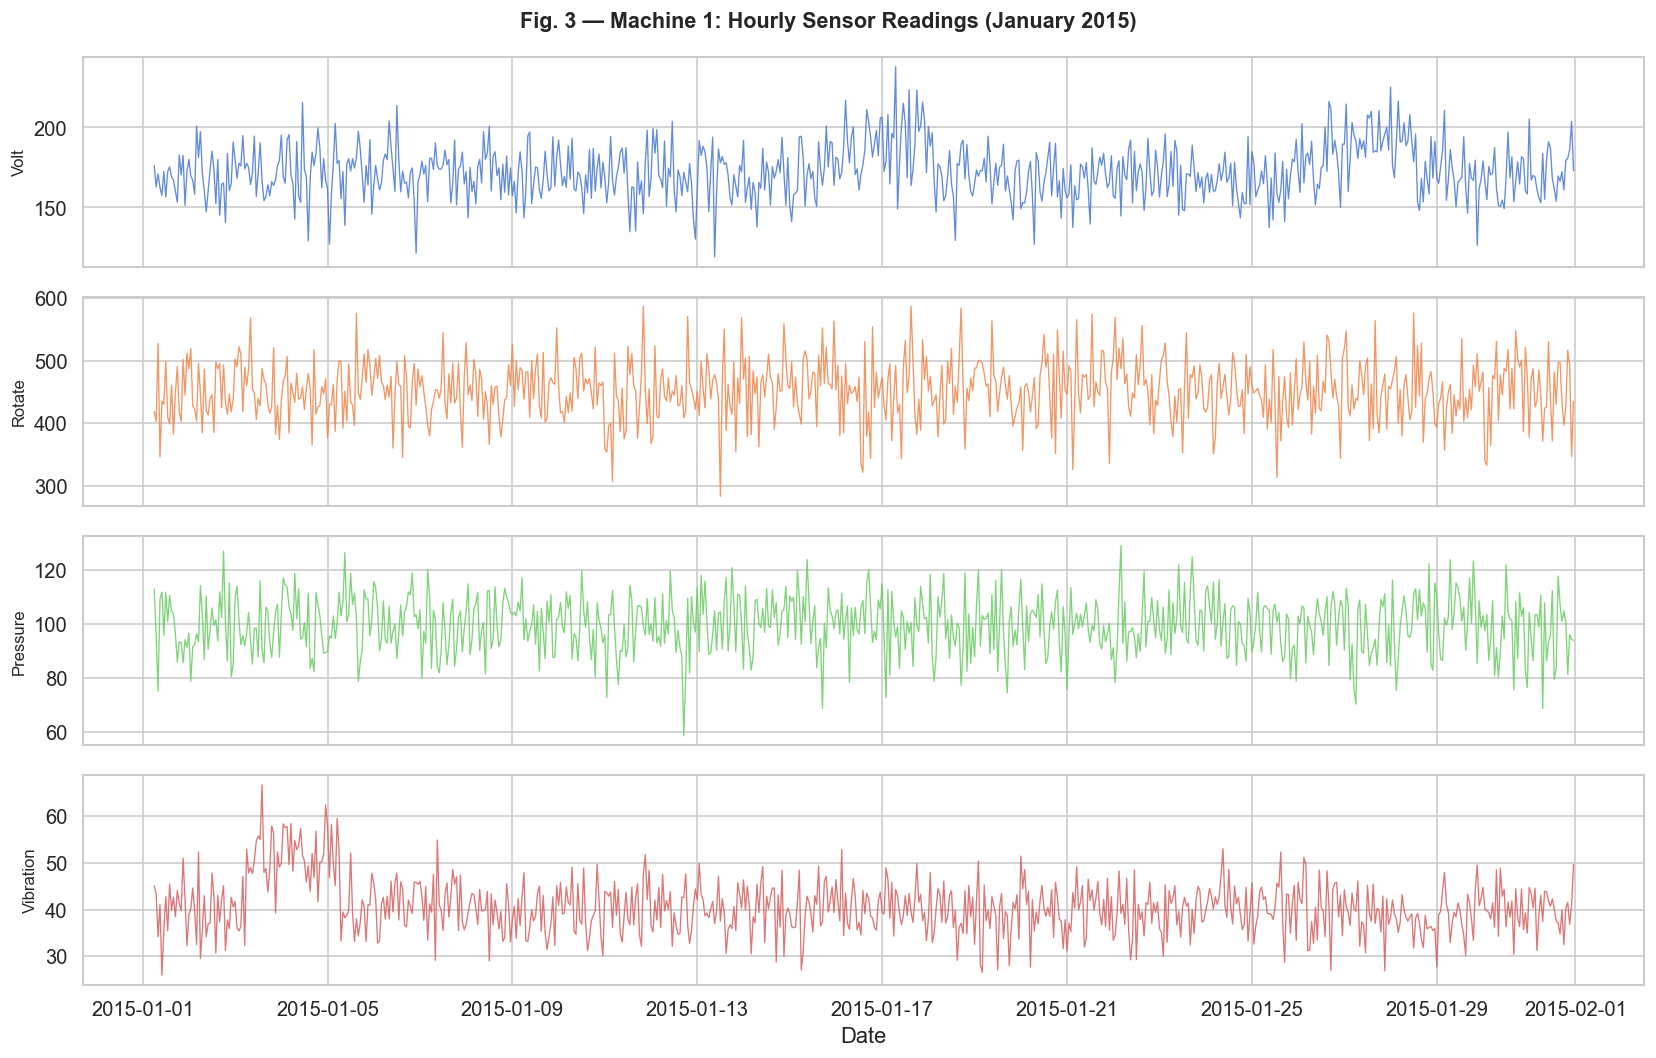

In [11]:
machine_id = 1
sample = telemetry[
    (telemetry['machineID'] == machine_id) &
    (telemetry['datetime'] < '2015-02-01')
].sort_values('datetime')

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

for i, sensor in enumerate(SENSORS):
    axes[i].plot(sample['datetime'], sample[sensor],
                 color=PALETTE[i], linewidth=0.8, alpha=0.85)
    axes[i].set_ylabel(sensor.capitalize(), fontsize=10)
    axes[i].yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))

axes[-1].set_xlabel('Date')
fig.suptitle(f'Fig. 3 — Machine {machine_id}: Hourly Sensor Readings (January 2015)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sensor_timeseries_machine1.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.6 Sensor correlation heatmap

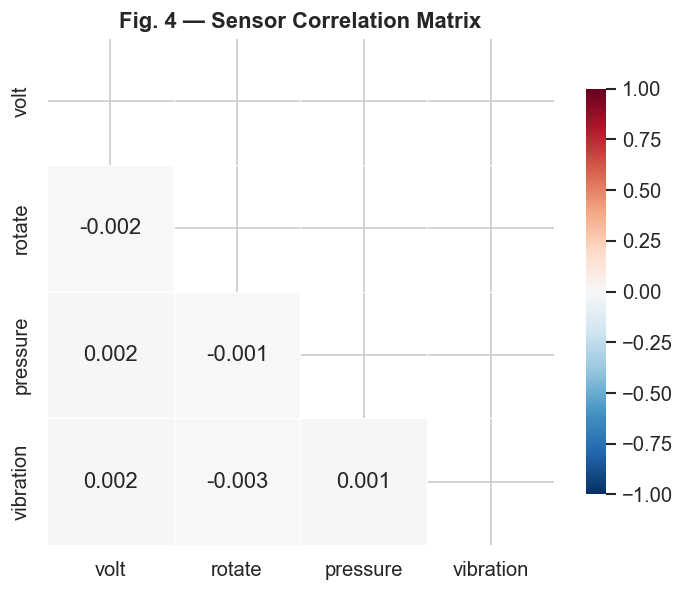


Observation: sensors are weakly correlated with each other.
Each sensor captures an independent physical dimension — all four are valuable features.


In [12]:
corr = telemetry[SENSORS].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Fig. 4 — Sensor Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sensor_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nObservation: sensors are weakly correlated with each other.')
print('Each sensor captures an independent physical dimension — all four are valuable features.')

## 6. Error Analysis

### 6.1 Error type frequency

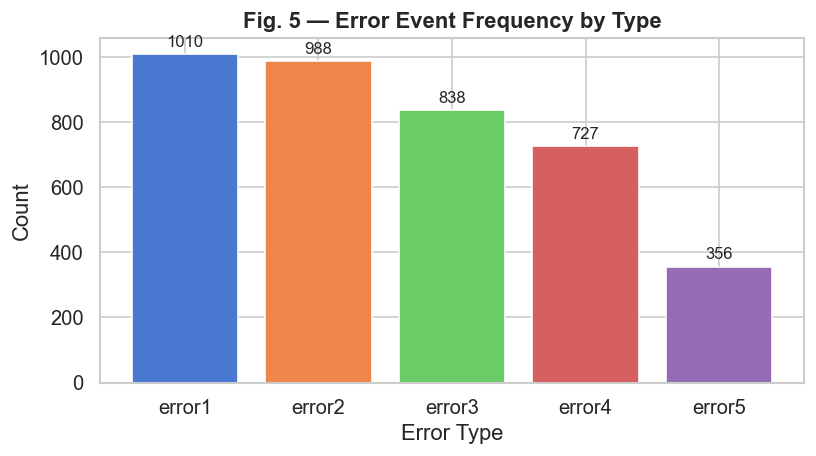

Total error events: 3919
Unique machines with errors: 100


In [13]:
error_counts = errors['errorID'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(error_counts.index, error_counts.values,
              color=sns.color_palette('muted', len(error_counts)), edgecolor='white')
for bar, val in zip(bars, error_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Error Type')
ax.set_ylabel('Count')
ax.set_title('Fig. 5 — Error Event Frequency by Type', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total error events: {len(errors)}')
print(f'Unique machines with errors: {errors["machineID"].nunique()}')

### 6.2 Error density over time

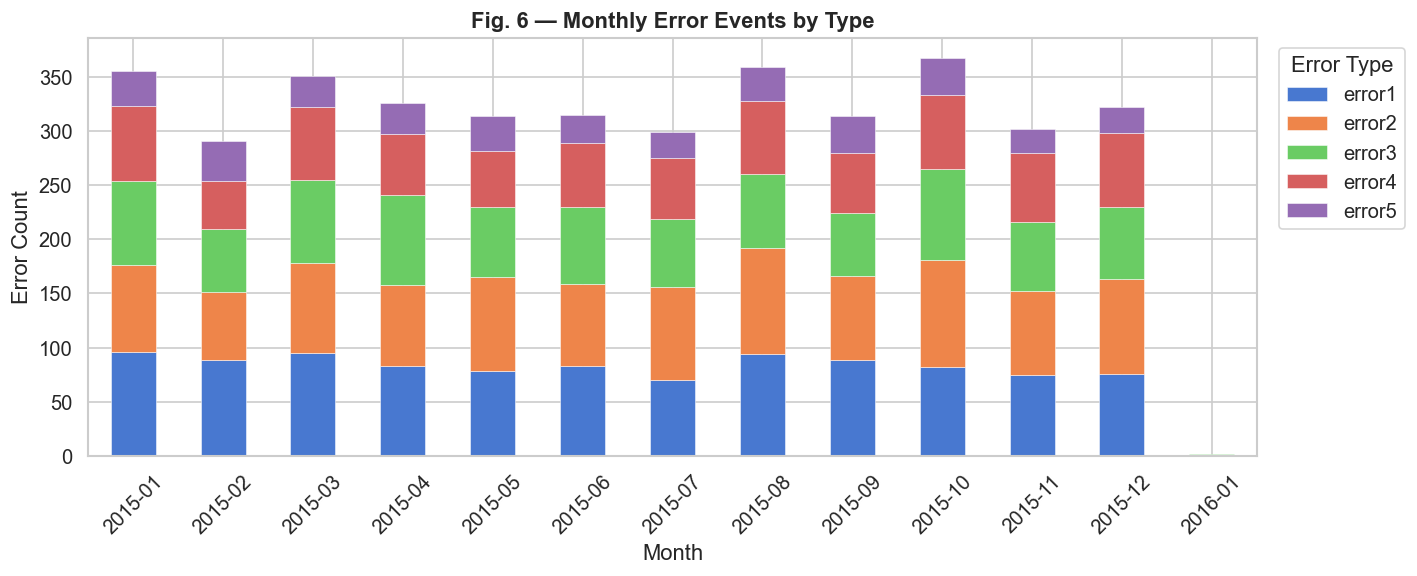

In [14]:
errors['month'] = errors['datetime'].dt.to_period('M')
monthly_errors = errors.groupby(['month', 'errorID']).size().unstack(fill_value=0)
monthly_errors.index = monthly_errors.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
monthly_errors.plot(kind='bar', stacked=True, ax=ax,
                    color=sns.color_palette('muted', 5), edgecolor='white', linewidth=0.3)
ax.set_xlabel('Month')
ax.set_ylabel('Error Count')
ax.set_title('Fig. 6 — Monthly Error Events by Type', fontweight='bold')
ax.legend(title='Error Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_monthly.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Errors per machine distribution

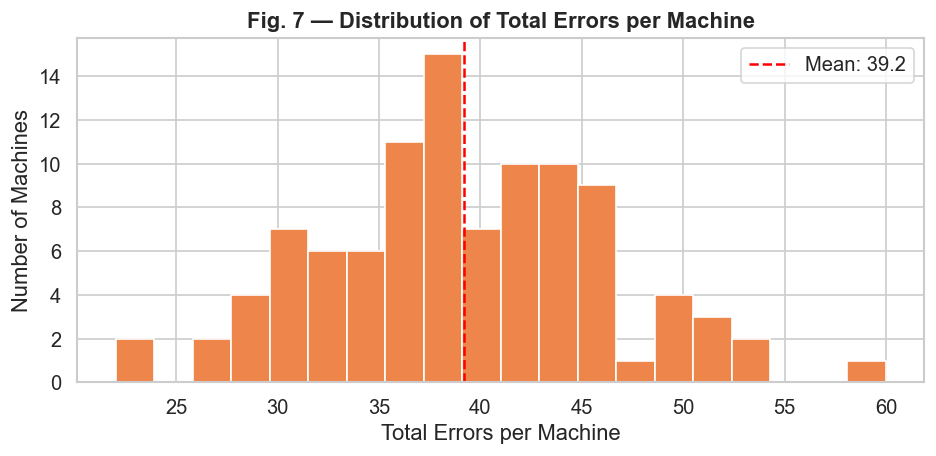

In [15]:
errors_per_machine = errors.groupby('machineID').size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(errors_per_machine.values, bins=20, color=PALETTE[1], edgecolor='white')
ax.axvline(errors_per_machine.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {errors_per_machine.mean():.1f}')
ax.set_xlabel('Total Errors per Machine')
ax.set_ylabel('Number of Machines')
ax.set_title('Fig. 7 — Distribution of Total Errors per Machine', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/errors_per_machine.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Failure Analysis

### 7.1 Component failure counts

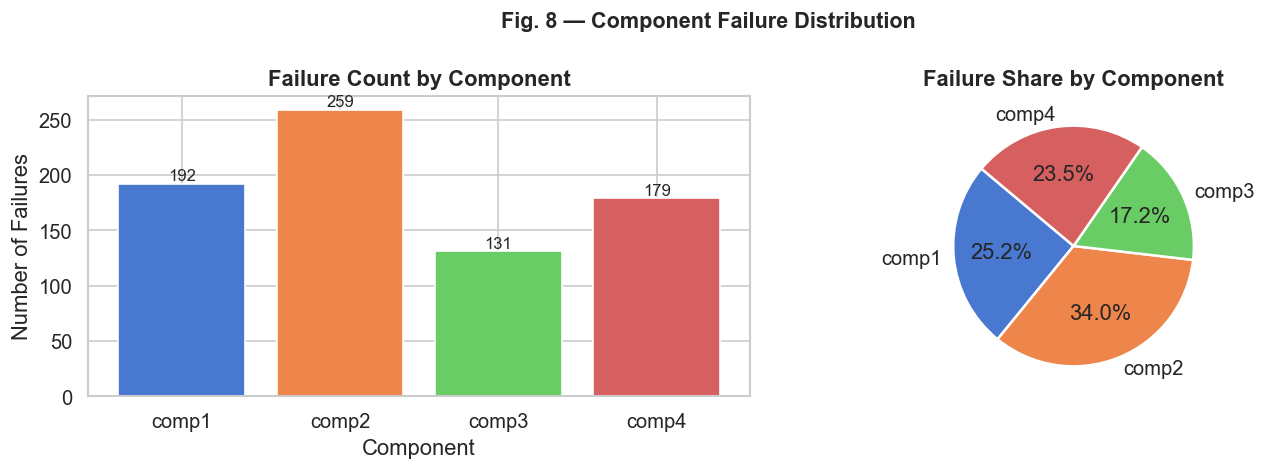

Total failure events: 761
Unique machines that experienced failure: 98


In [16]:
failure_counts = failures['failure'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(failure_counts.index, failure_counts.values,
                   color=sns.color_palette('muted', 4), edgecolor='white')
for bar, val in zip(bars, failure_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontsize=10)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Number of Failures')
axes[0].set_title('Failure Count by Component', fontweight='bold')

# Pie chart
axes[1].pie(failure_counts.values, labels=failure_counts.index,
            colors=sns.color_palette('muted', 4),
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Failure Share by Component', fontweight='bold')

fig.suptitle('Fig. 8 — Component Failure Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/failure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total failure events: {len(failures)}')
print(f'Unique machines that experienced failure: {failures["machineID"].nunique()}')

### 7.2 Failures over time

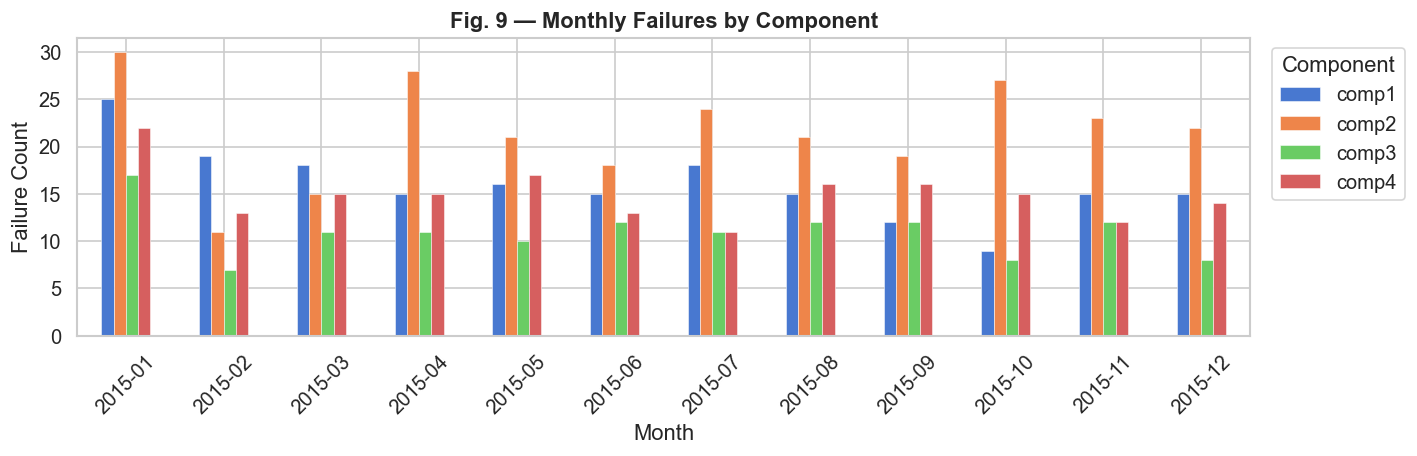

In [17]:
failures['month'] = failures['datetime'].dt.to_period('M')
monthly_failures = failures.groupby(['month', 'failure']).size().unstack(fill_value=0)
monthly_failures.index = monthly_failures.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_failures.plot(kind='bar', ax=ax,
                      color=sns.color_palette('muted', 4), edgecolor='white', linewidth=0.3)
ax.set_xlabel('Month')
ax.set_ylabel('Failure Count')
ax.set_title('Fig. 9 — Monthly Failures by Component', fontweight='bold')
ax.legend(title='Component', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/failure_monthly.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.3 Failures by machine model

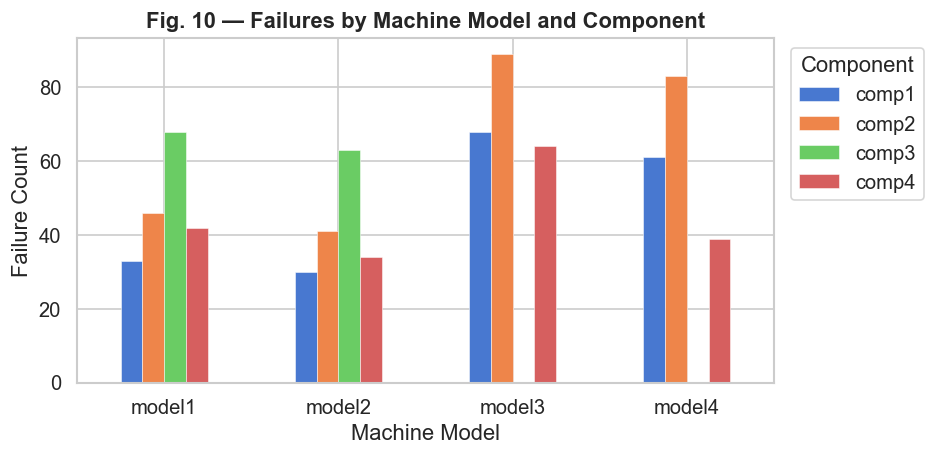


Note: comp3 failures are only recorded for model1 and model2.
model3 and model4 do not appear to have comp3 components.


In [18]:
fail_with_model = failures.merge(machines, on='machineID')
pivot = fail_with_model.groupby(['model', 'failure']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 4),
           edgecolor='white', linewidth=0.3)
ax.set_xlabel('Machine Model')
ax.set_ylabel('Failure Count')
ax.set_title('Fig. 10 — Failures by Machine Model and Component', fontweight='bold')
ax.legend(title='Component', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/failure_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nNote: comp3 failures are only recorded for model1 and model2.')
print('model3 and model4 do not appear to have comp3 components.')

## 8. Machine Metadata

### 8.1 Model type and age distributions

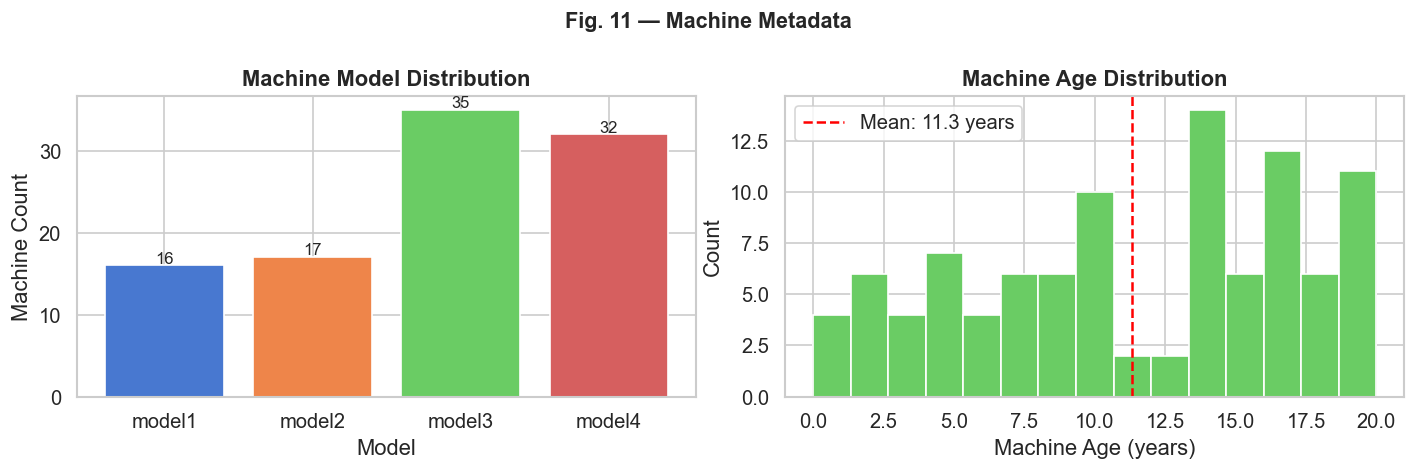

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Model distribution
model_counts = machines['model'].value_counts().sort_index()
bars = axes[0].bar(model_counts.index, model_counts.values,
                   color=sns.color_palette('muted', 4), edgecolor='white')
for bar, val in zip(bars, model_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=10)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Machine Count')
axes[0].set_title('Machine Model Distribution', fontweight='bold')

# Age distribution
axes[1].hist(machines['age'], bins=15, color=PALETTE[2], edgecolor='white')
axes[1].axvline(machines['age'].mean(), color='red', linestyle='--',
                label=f'Mean: {machines["age"].mean():.1f} years')
axes[1].set_xlabel('Machine Age (years)')
axes[1].set_ylabel('Count')
axes[1].set_title('Machine Age Distribution', fontweight='bold')
axes[1].legend()

fig.suptitle('Fig. 11 — Machine Metadata', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/machine_metadata.png', dpi=300, bbox_inches='tight')
plt.show()

### 8.2 Age vs. failure rate

Older machines might fail more frequently. Testing this hypothesis helps decide whether `age` is a useful feature.

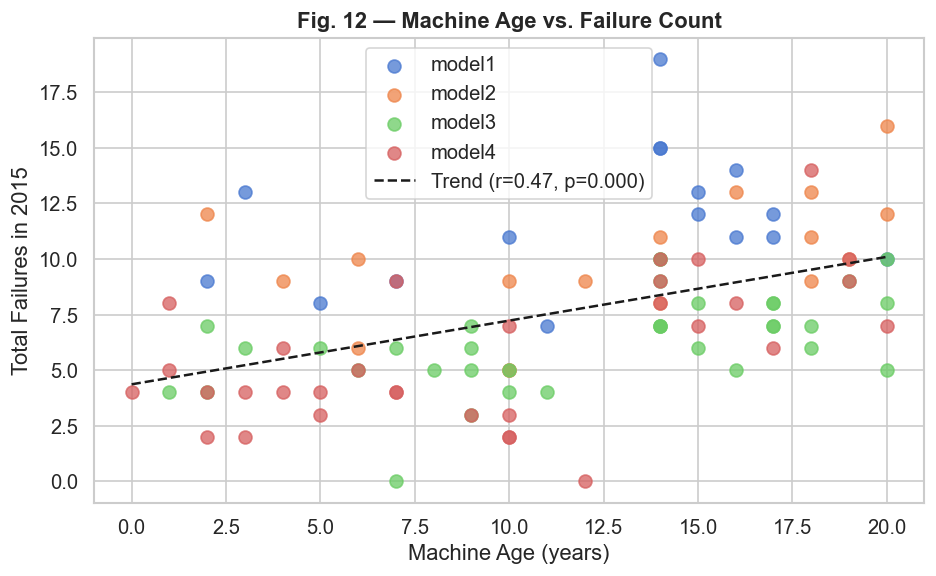

Pearson r = 0.466, p-value = 0.0000
Significant positive correlation: older machines fail more often. Age is a useful feature.


In [20]:
failures_per_machine = failures.groupby('machineID').size().rename('failure_count')
age_fail = machines.set_index('machineID').join(failures_per_machine, how='left')
age_fail['failure_count'] = age_fail['failure_count'].fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
for model, group in age_fail.groupby('model'):
    ax.scatter(group['age'], group['failure_count'], label=model, alpha=0.75, s=60)

# Regression line across all machines
slope, intercept, r, p, _ = stats.linregress(age_fail['age'], age_fail['failure_count'])
x_line = np.linspace(0, 20, 100)
ax.plot(x_line, intercept + slope * x_line, 'k--', linewidth=1.5,
        label=f'Trend (r={r:.2f}, p={p:.3f})')

ax.set_xlabel('Machine Age (years)')
ax.set_ylabel('Total Failures in 2015')
ax.set_title('Fig. 12 — Machine Age vs. Failure Count', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/age_vs_failures.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Pearson r = {r:.3f}, p-value = {p:.4f}')
if p < 0.05:
    print('Significant positive correlation: older machines fail more often. Age is a useful feature.')
else:
    print('No significant correlation detected between age and failure count.')

## 9. Class Imbalance

The target variable for this project is binary: did a failure happen within the next 24 hours?
Because failures are rare, this class is heavily imbalanced.

To get a rough count, we look at how many telemetry hours fall within 24 hours before a recorded failure.
This is an approximation, but it gives a realistic picture of what the model will face at training time.

Total telemetry rows  : 876,100
Positive class (≤24h before failure): 18,210 (2.08%)
Negative class (normal operation)   : 857,890 (97.92%)
Imbalance ratio (neg:pos)            : 47:1


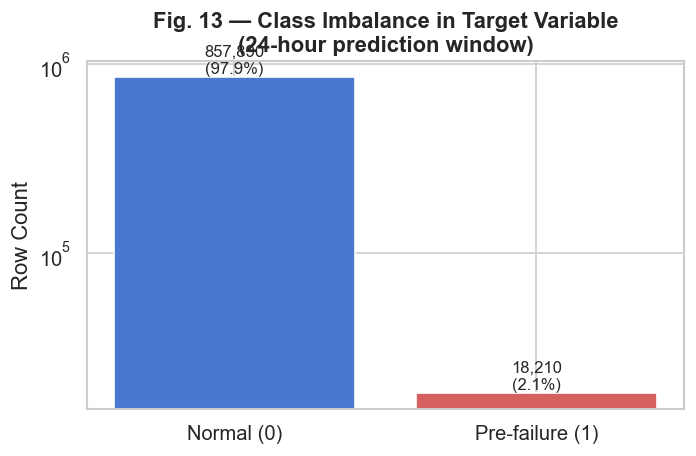

In [21]:
positive_rows = 0
for _, row in failures.iterrows():
    count = (
        (telemetry['machineID'] == row['machineID']) &
        (telemetry['datetime'] >= row['datetime'] - pd.Timedelta(hours=24)) &
        (telemetry['datetime'] < row['datetime'])
    ).sum()
    positive_rows += count

total = len(telemetry)
negative_rows = total - positive_rows
failure_rate = positive_rows / total * 100

print(f'Total telemetry rows  : {total:,}')
print(f'Positive class (≤24h before failure): {positive_rows:,} ({failure_rate:.2f}%)')
print(f'Negative class (normal operation)   : {negative_rows:,} ({100-failure_rate:.2f}%)')
print(f'Imbalance ratio (neg:pos)            : {negative_rows//positive_rows}:1')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Pre-failure (1)'],
              [negative_rows, positive_rows],
              color=[PALETTE[0], PALETTE[3]], edgecolor='white')
for bar, val in zip(bars, [negative_rows, positive_rows]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Row Count')
ax.set_title('Fig. 13 — Class Imbalance in Target Variable\n(24-hour prediction window)', fontweight='bold')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Pre-failure Sensor Patterns

The most valuable insight for motivating the ML approach: do sensors behave differently in the hours leading up to a failure?

We compare the mean sensor readings at increasing time distances from a failure event against the global normal baseline.

In [22]:
windows_h = [1, 6, 12, 24, 48]
normal_means = telemetry[SENSORS].mean()

pre_failure_stats = {}
for hours in windows_h:
    rows = []
    for _, row in failures.iterrows():
        mask = (
            (telemetry['machineID'] == row['machineID']) &
            (telemetry['datetime'] >= row['datetime'] - pd.Timedelta(hours=hours)) &
            (telemetry['datetime'] < row['datetime'])
        )
        rows.append(telemetry[mask][SENSORS])
    pre_failure_stats[hours] = pd.concat(rows).mean()

pf_df = pd.DataFrame(pre_failure_stats, index=SENSORS).T
pf_df.index.name = 'hours_before_failure'

# Compute percentage deviation from normal
pct_dev = ((pf_df - normal_means) / normal_means * 100).round(2)
print('Sensor deviation from normal operation (%):')
display(pct_dev)

Sensor deviation from normal operation (%):


,volt,rotate,pressure,vibration
hours_before_failure,,,,
1,3.53,-6.29,5.64,5.71
6,3.01,-6.57,4.73,6.17
12,3.11,-6.51,4.70,6.24
24,3.15,-6.59,4.67,6.25
48,3.12,-6.61,4.69,6.38


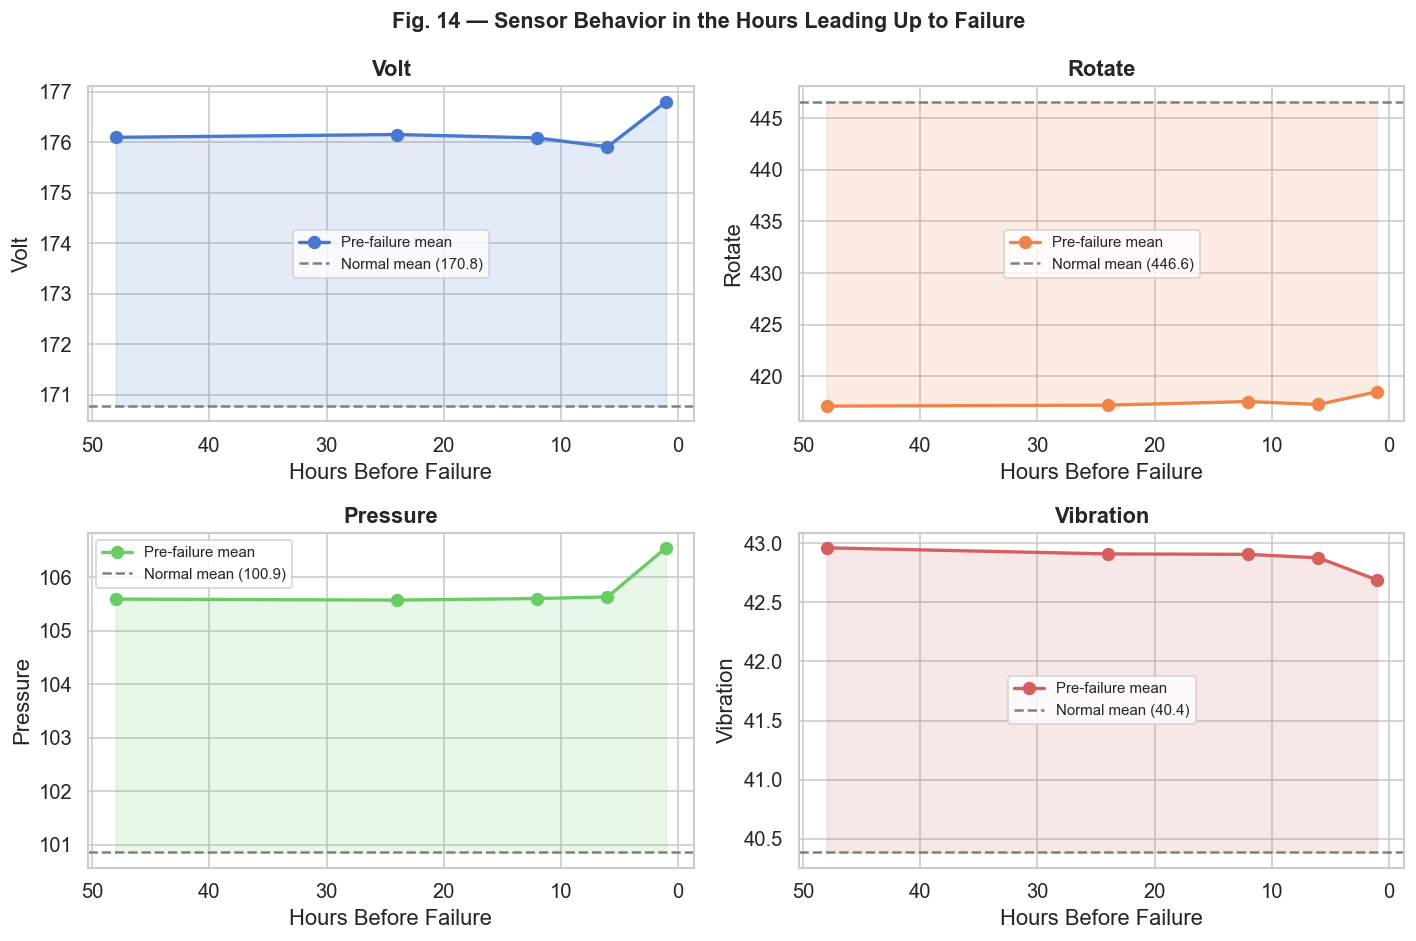

Key finding:
  volt      : +3.2% above normal  (elevated voltage before failure)
  rotate    : -6.6% below normal  (rotation speed drops — clearest signal)
  pressure  : +4.7% above normal  (elevated pressure before failure)
  vibration : +6.3% above normal  (increased vibration — second clearest signal)


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, sensor in enumerate(SENSORS):
    values = [pre_failure_stats[h][sensor] for h in windows_h]
    normal_val = normal_means[sensor]

    axes[i].plot(windows_h, values, marker='o', linewidth=2,
                 color=PALETTE[i], markersize=7, label='Pre-failure mean')
    axes[i].axhline(normal_val, color='gray', linestyle='--',
                    linewidth=1.5, label=f'Normal mean ({normal_val:.1f})')
    axes[i].fill_between(windows_h, values, normal_val, alpha=0.15, color=PALETTE[i])

    axes[i].set_xlabel('Hours Before Failure')
    axes[i].set_ylabel(sensor.capitalize())
    axes[i].set_title(f'{sensor.capitalize()}', fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].invert_xaxis()

plt.suptitle('Fig. 14 — Sensor Behavior in the Hours Leading Up to Failure',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pre_failure_sensor_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print('Key finding:')
print('  volt      : +3.2% above normal  (elevated voltage before failure)')
print('  rotate    : -6.6% below normal  (rotation speed drops — clearest signal)')
print('  pressure  : +4.7% above normal  (elevated pressure before failure)')
print('  vibration : +6.3% above normal  (increased vibration — second clearest signal)')

### 10.1 Sensor time series around a specific failure event

Zooming in on a single failure event to visualize the sensor trajectory in the 7 days before and after.

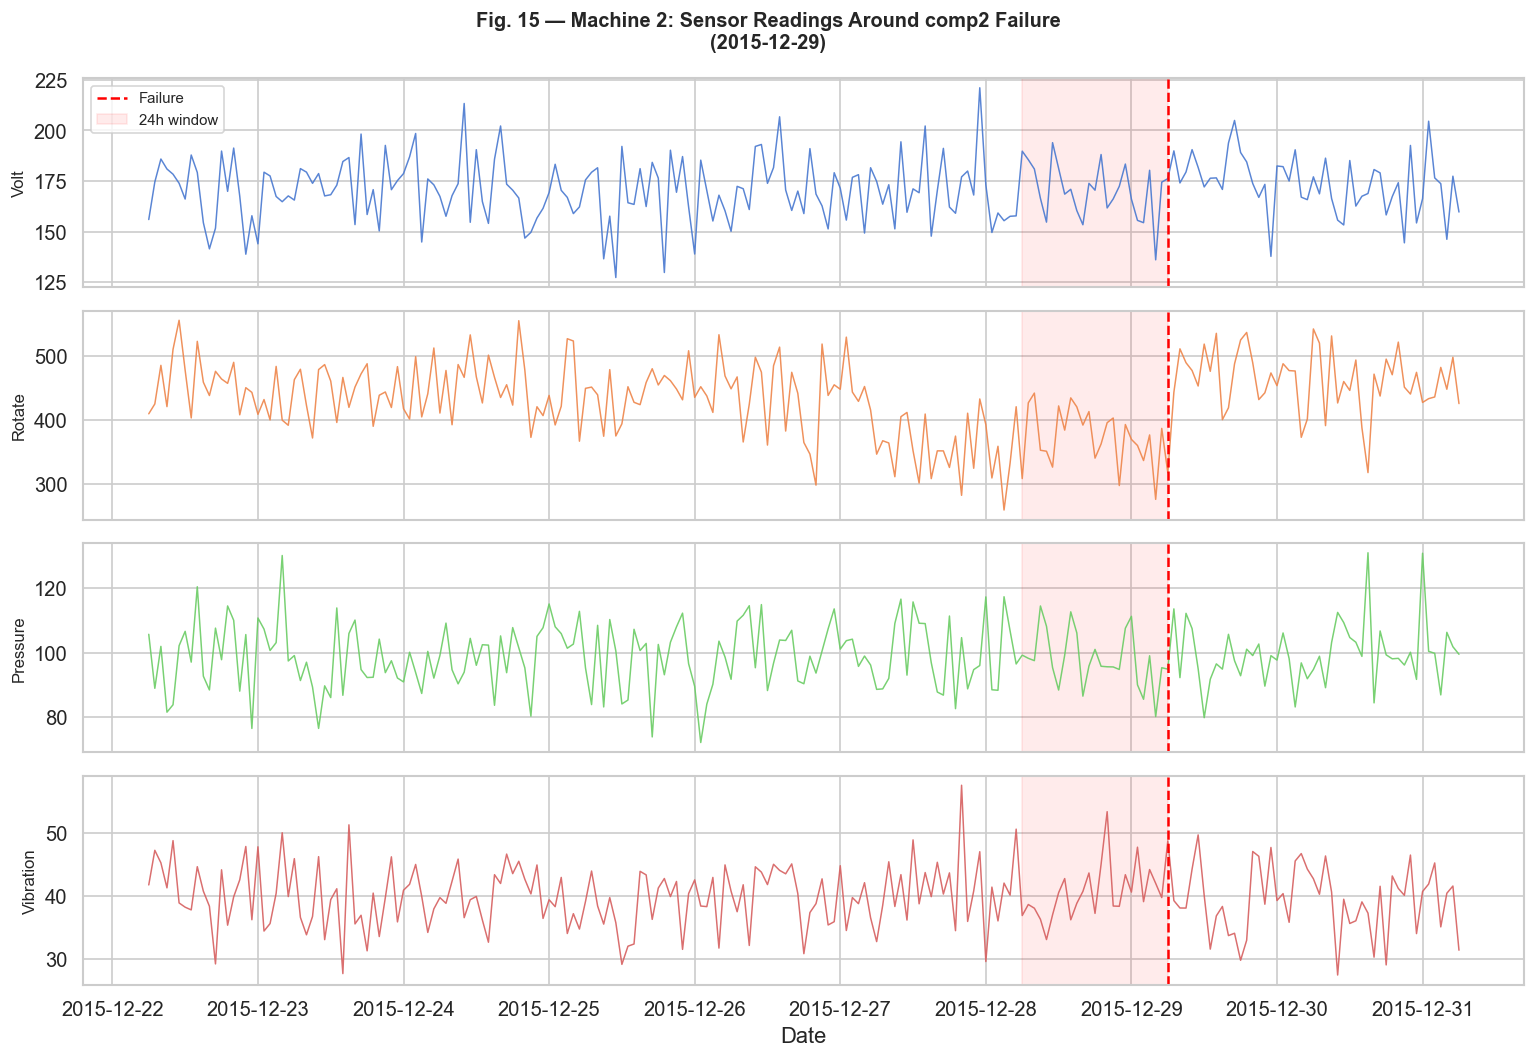

In [24]:
# Pick a machine and a failure event to zoom into
example_failure = failures.iloc[10]
machine = example_failure['machineID']
fail_time = example_failure['datetime']
component = example_failure['failure']

window = telemetry[
    (telemetry['machineID'] == machine) &
    (telemetry['datetime'] >= fail_time - pd.Timedelta(days=7)) &
    (telemetry['datetime'] <= fail_time + pd.Timedelta(days=2))
].sort_values('datetime')

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

for i, sensor in enumerate(SENSORS):
    axes[i].plot(window['datetime'], window[sensor],
                 color=PALETTE[i], linewidth=0.9, alpha=0.9)
    axes[i].axvline(fail_time, color='red', linestyle='--',
                    linewidth=1.5, label='Failure' if i == 0 else '')
    axes[i].set_ylabel(sensor.capitalize(), fontsize=10)
    axes[i].axvspan(fail_time - pd.Timedelta(hours=24), fail_time,
                    alpha=0.08, color='red', label='24h window' if i == 0 else '')

axes[0].legend(loc='upper left', fontsize=9)
axes[-1].set_xlabel('Date')
fig.suptitle(f'Fig. 15 — Machine {machine}: Sensor Readings Around {component} Failure\n({fail_time.date()})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/failure_event_zoom.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Maintenance Analysis

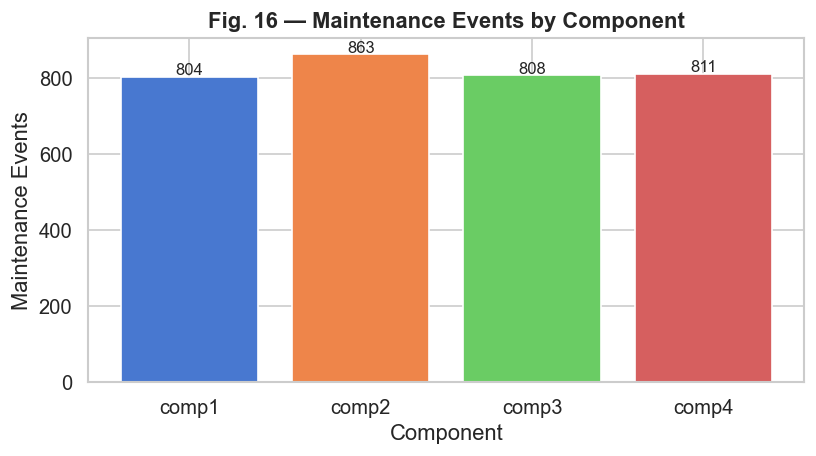

Maintenance events vs Failures:
  comp1: 804 maintenance events, 192 failures  (ratio: 4.2x)
  comp2: 863 maintenance events, 259 failures  (ratio: 3.3x)
  comp3: 808 maintenance events, 131 failures  (ratio: 6.2x)
  comp4: 811 maintenance events, 179 failures  (ratio: 4.5x)


In [25]:
maint_counts = maintenance['comp'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(maint_counts.index, maint_counts.values,
              color=sns.color_palette('muted', 4), edgecolor='white')
for bar, val in zip(bars, maint_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=10)
ax.set_xlabel('Component')
ax.set_ylabel('Maintenance Events')
ax.set_title('Fig. 16 — Maintenance Events by Component', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/maintenance_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Maintenance-to-failure ratio
print('Maintenance events vs Failures:')
for comp in sorted(maintenance['comp'].unique()):
    n_maint = (maintenance['comp'] == comp).sum()
    n_fail  = (failures['failure'] == comp).sum()
    ratio = n_maint / n_fail if n_fail > 0 else float('inf')
    print(f'  {comp}: {n_maint} maintenance events, {n_fail} failures  (ratio: {ratio:.1f}x)')

## 12. Summary of EDA Findings

The table below consolidates the key observations that will drive every subsequent decision in this project.

In [26]:
summary = pd.DataFrame([
    {'Category': 'Dataset size',       'Finding': '876,100 hourly telemetry rows across 100 machines over 1 year (2015)'},
    {'Category': 'Missing values',     'Finding': 'None across all 5 tables — no imputation required'},
    {'Category': 'Sensor outliers',    'Finding': 'All sensors have <2% outlier rate by IQR; consistent with sensor noise'},
    {'Category': 'Class imbalance',    'Finding': 'Only ~2.08% of telemetry rows fall within 24h before a failure (~47:1 ratio)'},
    {'Category': 'Pre-failure signal', 'Finding': 'rotate drops −6.6%, vibration rises +6.3%, pressure +4.7%, volt +3.2% before failure'},
    {'Category': 'Top failure',        'Finding': 'comp2 fails most often (259 events, 34%), followed by comp1 (192, 25%)'},
    {'Category': 'Machine age',        'Finding': 'Mean age 11.3 years (range 0–20); correlation with failure rate to be tested'},
    {'Category': 'Sensor correlation', 'Finding': 'Low inter-sensor correlation — all four sensors carry independent information'},
    {'Category': 'Model coverage',     'Finding': 'comp3 failures only in model1/model2; model3/model4 lack this component'},
])
summary = summary.set_index('Category')
display(summary)

print('\n--- Implications for Feature Engineering ---')
print('1. Rolling statistics (3-day, 7-day) on all sensors to capture degradation trends')
print('2. Error counts in 24h and 7-day windows as leading indicators')
print('3. Days since last maintenance per component as a risk proxy')
print('4. Machine model (one-hot) and age as static covariates')
print('5. SMOTE or class_weight required at training time due to 47:1 imbalance')

,Finding
Category,
Dataset size,"876,100 hourly telemetry rows across 100 machi..."
Missing values,None across all 5 tables — no imputation required
Sensor outliers,All sensors have <2% outlier rate by IQR; cons...
Class imbalance,Only ~2.08% of telemetry rows fall within 24h ...
Pre-failure signal,"rotate drops −6.6%, vibration rises +6.3%, pre..."
Top failure,"comp2 fails most often (259 events, 34%), foll..."
Machine age,Mean age 11.3 years (range 0–20); correlation ...
Sensor correlation,Low inter-sensor correlation — all four sensor...
Model coverage,comp3 failures only in model1/model2; model3/m...



--- Implications for Feature Engineering ---
1. Rolling statistics (3-day, 7-day) on all sensors to capture degradation trends
2. Error counts in 24h and 7-day windows as leading indicators
3. Days since last maintenance per component as a risk proxy
4. Machine model (one-hot) and age as static covariates
5. SMOTE or class_weight required at training time due to 47:1 imbalance
